## Plot branchwater output
Used branchwater to look for microbes that are common in pig gut. 
Returns metagenomes. Count for each metagenome how many of these microbes are present. 
If more of these microbes (out of N) are present, is the metagenome likely to be pig? (yes)

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2026-pancoding-core/'

BP_THRESHOLD=20000

BASE_OUTPUTS=BASE+'/outputs.branchwater/parquet/'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

### Set up human/pig/other labels.

In [3]:
# remove shitty entries with shitty metatada
unnannotated_values = [
    "metagenome",
    "gut metagenome",
    "feces metagenome",
    "manure metagenome",
    "bacterium",
    "unidentified",
    "null"
    ]
def remove_unnannotated(df: pl.DataFrame) -> pl.DataFrame:
    return df.filter(~pl.col("organism").is_in(unnannotated_values))


# group by organism and count number of bacteria per SRA 
def pivot_count(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by(["broad_cat", "count"])
        .len()  # count occurrences
        .pivot(
            values="len",
            index="broad_cat",
            on="count"
        )
        .fill_null(0)  # optional: fill missing with 0
    )

# set mapping for "categories of interest" I like human v pig v neither. 
category_map_simple = {
    'human associated': ['human', 'homo', 'sapiens'],
    'pig': ['pig', 'sus', 'scrofa']}

# Function to assign category based on keywords above
def get_broad_cat_simple(organism):
    for cat, keywords in category_map_simple.items():
        if any(keyword.lower() in str(organism).lower() for keyword in keywords):
            return cat
    return 'other'  

# colormap plotting
colors = {
    'pig': '#264653',
    'human associated': '#e76f51',
    'other': '#f4a261',
    'pig/other': '#2a9d8f',
    'pig-associated': '#e9c46a'
    }

### Load the cds3 manysearch results

In [4]:
dirpath = BASE_OUTPUTS+'/manysearch.*.parquet'

raw_bw_df = (pl.scan_parquet(dirpath).with_columns(
    # remove singlehash from name
    species=pl.col('query_name').str.split(' ').list.slice(1, 2).list.join( " "),
    acc=pl.col("match_name"),
    intersect_bp=pl.col("scaled")*pl.col("intersect_hashes"),
).select(["species", "acc", "containment", "intersect_bp"])
).collect()

n_species = raw_bw_df['species'].n_unique()
n_acc = raw_bw_df['acc'].n_unique()
print(f"loaded {len(raw_bw_df)} branchwater results for {n_species} species containing {n_acc} metagenomes")

loaded 6123721 branchwater results for 16 species containing 688718 metagenomes


### Filter out the metagenomes we used to _find_ the core species

After all, we already know the species are in those!

In [5]:
names_3216_df = (pl.read_csv('../3216.manifest.csv')
                 .with_columns(acc=pl.col('name'))
                 ['acc'].unique().to_frame()
                )
assert len(names_3216_df) == 3216, len(names_3216_df)
names_3216 = set(names_3216_df['acc'].to_list())

filtered_bw_df = raw_bw_df.filter(~(pl.col('acc').is_in(names_3216)))
n_species = filtered_bw_df['species'].n_unique()
n_acc = filtered_bw_df['acc'].n_unique()

print(f"remaining after removing 3216 metag: {len(filtered_bw_df)} branchwater results for {n_species} species containing {n_acc} metagenomes")

remaining after removing 3216 metag: 6072394 branchwater results for 16 species containing 685502 metagenomes


### Load metadata for datasets & get rid of non-WGS datasets

In [6]:
# get metadata, only compare WGS
metadata_df = (
    pl.scan_parquet("/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet")
    .filter(pl.col("acc") != "NP")
    .filter(pl.col("assay_type") == "WGS")
#    .select(["acc", "organism", "bioproject", "mbases", "host", "project_name"]) 
    .collect()
)
print(f"found metadata records for {len(metadata_df)} WGS metagenome data sets from the SRA")

found metadata records for 703916 WGS metagenome data sets from the SRA


In [7]:
big_names_df = pl.read_csv('../inputs.branchwater/wort-acc-gt-1e6.csv')

### Create a new dataframe that will provide a 'simpleorg' column: human, pig, other

In [8]:
rename_df = []
for organism in metadata_df['organism'].unique().to_list():
    simpleorg = 'other'
    if organism:
        for kw in ['human', 'homo']:
            if kw in organism.lower():
                simpleorg = 'human'
                break
        for kw in ['pig', 'sus', 'scrofa']:
            if kw in organism.lower():
                simpleorg = 'pig'
                break
    rename_df.append(dict(organism=organism, broad_cat=simpleorg))

rename_df = pl.DataFrame(rename_df)
rename_df['broad_cat'].value_counts().sort(by='count', descending=True)

broad_cat,count
str,u32
"""other""",10208
"""human""",165
"""pig""",36


### Apply the renaming to the metadata table => metadata2_df

In [9]:
metadata2_df = metadata_df.join(rename_df, on='organism', how='inner', coalesce=True)
assert len(metadata2_df) == len(metadata_df)
metadata2_df

sample_name,sample_name_sam,acc,assay_type,avgspotlen,bioproject,biosample,biosamplemodel_sam,center_name,collection_date_sam,consent,datastore_filetype,datastore_provider,datastore_region,ena_first_public_run,ena_last_update_run,experiment,geo_loc_name_country_calc,geo_loc_name_country_continent_calc,geo_loc_name_sam,insertsize,instrument,library_name,librarylayout,libraryselection,librarysource,loaddate,mbases,mbytes,organism,platform,releasedate,sample_acc,sra_study,age,altitude,body_habitat,body_product,collection_date,depth,env_biome,env_broad_scale,env_feature,env_local_scale,env_material,env_medium,env_package,host,host_age,host_body_habitat,host_body_product,host_common_name,host_sex,host_subject_id,host_taxid,investigation_type,isolate,lat_lon,project_name,race,sample_type,source_material_id,bases,bytes,run_file_create_date,run_file_version,primary_search,broad_cat
str,list[str],str,str,i64,str,str,list[str],str,date,str,list[str],list[str],list[str],list[str],list[str],str,str,str,list[str],i64,str,str,str,str,str,"datetime[μs, UTC]",i64,i64,str,str,"datetime[μs, UTC]",str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""27""",[],"""SRR28523869""","""WGS""",5336,"""PRJNA1095378""","""SAMN40717046""","[""MIMARKS.survey"", ""MIGS/MIMS/MIMARKS.human-associated""]","""UNIVERSITY OF FLORIDA""",2019-01-21,"""public""","[""fastq"", ""sra""]","[""gs"", ""ncbi"", ""s3""]","[""gs.us-east1"", ""ncbi.public"", ""s3.us-east-1""]",[],[],"""SRX24124678""","""USA""","""North America""","[""USA""]",null,"""MinION""","""27""","""SINGLE""","""RANDOM""","""METAGENOMIC""",null,258,221,"""human metagenome""","""OXFORD_NANOPORE""",2024-04-02 00:00:00 UTC,"""SRS20910198""","""SRP499205""",null,null,null,null,"""[""2019-01-21""]""",null,null,"""[""human stool""]""",null,"""[""preterm neonate stool""]""",null,"""[""not applicable""]""",null,"""[""Homo sapiens""]""",null,null,null,null,null,null,null,null,null,"""""29.6520 N 82.3250 W""""",null,null,null,null,"""258178589""","""232696690""","""""2024-04-02T09:18:00.000Z""""",null,"""""1095378""""","""human"""
"""CN20""",[],"""SRR19901137""","""WGS""",709,"""PRJNA854064""","""SAMN29417614""","[""Pathogen.cl""]","""ACADEMY OF MILITARY MEDICAL SC…",null,"""public""","[""fastq"", ""run.zq"", ""sra""]","[""gs"", ""ncbi"", ""s3""]","[""gs.us-east1"", ""ncbi.public"", ""s3.us-east-1""]",[],[],"""SRX15943916""","""China""","""Asia""","[""China""]",null,"""MinION""","""CN20""","""SINGLE""","""RANDOM PCR""","""METAGENOMIC""",null,40,35,"""Streptococcus suis""","""OXFORD_NANOPORE""",2022-06-29 00:00:00 UTC,"""SRS13630891""","""SRP384224""",null,null,null,null,"""[""2020""]""",null,null,null,null,null,null,null,null,"""[""Homo sapiens""]""",null,null,null,null,null,null,null,null,null,"""""39.56 N 116.246 E""""",null,null,null,null,"""40695094""","""37326224""","""""2022-06-29T14:47:00.000Z""""",null,"""""29417614""""","""other"""
"""9419-17""",[],"""SRR24962475""","""WGS""",2830,"""PRJNA982891""","""SAMN35766867""","[""Pathogen.cl""]","""UNIVERSITY OF QUEENSLAND""",null,"""public""","[""fastq"", ""sra""]","[""gs"", ""ncbi"", ""s3""]","[""gs.us-east1"", ""ncbi.public"", ""s3.us-east-1""]",[],[],"""SRX20720528""","""Australia""","""Oceania""","[""Australia""]",null,"""MinION""","""9419-17ONTBC""","""SINGLE""","""RANDOM""","""METAGENOMIC""",null,88,77,"""Escherichia coli""","""OXFORD_NANOPORE""",2023-06-19 00:00:00 UTC,"""SRS18011968""","""SRP444682""",null,null,null,null,"""[""2021""]""",null,null,null,null,null,null,null,null,"""[""Homo sapiens""]""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""88439849""","""81459369""","""""2023-06-19T19:32:00.000Z""""",null,"""""35766867""""","""other"""
"""P36""",[],"""SRR29161330""","""WGS""",1250,"""PRJNA1116137""","""SAMN41523629""","[""Metagenome or environmental""]","""THE OHIO STATE UNIVERSITY""",2018-04-13,"""public""","[""fastq"", ""sra""]"

In [10]:
n_pig = len(metadata2_df.filter(pl.col('broad_cat') == 'pig'))
n_human = len(metadata2_df.filter(pl.col('broad_cat') == 'human'))

print(f"{n_pig} pig, {n_human} human metag")

9500 pig, 303365 human metag


### Bring in the metadata to the branchwater dataframe

In [11]:
bw_metadata_df = filtered_bw_df.join(metadata2_df, on="acc", how="inner")
print(f"{bw_metadata_df['species'].n_unique()} species, {bw_metadata_df['acc'].n_unique()} metagenomes")

16 species, 567031 metagenomes


In [12]:
bw_remove_df = bw_metadata_df.join(big_names_df, left_on='acc', right_on='name', how='anti')
print(len(bw_metadata_df), len(bw_remove_df))
print(f"{bw_remove_df['species'].n_unique()} species, {bw_remove_df['acc'].n_unique()} metagenomes")

5209753 3363653
16 species, 447817 metagenomes


### Create a core_bw_df that has just the core species records in it 

In [13]:
CORE_SPECIES=set([ x.strip() for x in open('../inputs.branchwater/names.list') ])
core_bw_df = bw_remove_df.filter(pl.col("species").is_in(CORE_SPECIES))
print(f"{core_bw_df['species'].n_unique()} species left after filtering for core; {core_bw_df['acc'].n_unique()} metagenomes")
assert core_bw_df['species'].n_unique() == len(CORE_SPECIES)

16 species left after filtering for core; 447817 metagenomes


### Also create a negative df that has only the non-core species records in it

In [14]:
neg_bw_df = bw_remove_df.filter(~(pl.col("species").is_in(CORE_SPECIES)))
print(f"NEGATIVE: {neg_bw_df['species'].n_unique()} species left after REMOVING core")
print(neg_bw_df['species'].unique().to_list())

NEGATIVE: 0 species left after REMOVING core
[]


In [15]:
# apply hash threshold
bw_df = core_bw_df.filter(pl.col("intersect_bp") >= BP_THRESHOLD)

# remove unnanotated metags (metagenome, gut metagenome, etc)
df = remove_unnannotated(bw_df)

# update with organism broad category
df = df.join(rename_df, on='organism', how='inner')

print(f'Removed unnanotated & added simpleorg: {len(bw_df)} -> {len(df)} (-{len(bw_df) - len(df)})')

# count number of orgs (out of 16) in each mG
counts_df = (
    df
    .group_by(["acc", "broad_cat"]).agg(
        pl.len().alias("count")
    )
)

print(counts_df)

# pivot for plotting
pl_dfp = pivot_count(counts_df)

# sort columns by number
assert pl_dfp.columns[0] == 'broad_cat'
sorted_cols = list(sorted(pl_dfp.columns[1:], key=lambda x: int(x)))
pl_dfp = pl_dfp.select(['broad_cat'] + sorted_cols)

print(pl_dfp)

Removed unnanotated & added simpleorg: 105757 -> 81204 (-24553)
shape: (32_404, 3)
┌─────────────┬───────────┬───────┐
│ acc         ┆ broad_cat ┆ count │
│ ---         ┆ ---       ┆ ---   │
│ str         ┆ str       ┆ u32   │
╞═════════════╪═══════════╪═══════╡
│ SRR2938217  ┆ other     ┆ 4     │
│ ERR8262341  ┆ human     ┆ 1     │
│ SRR27558771 ┆ other     ┆ 1     │
│ SRR18960522 ┆ human     ┆ 1     │
│ ERR1135745  ┆ pig       ┆ 1     │
│ …           ┆ …         ┆ …     │
│ ERR11569603 ┆ human     ┆ 1     │
│ SRR28738845 ┆ other     ┆ 4     │
│ ERR10786368 ┆ human     ┆ 1     │
│ ERR1728456  ┆ human     ┆ 2     │
│ ERR2709555  ┆ human     ┆ 2     │
└─────────────┴───────────┴───────┘
shape: (3, 17)
┌───────────┬───────┬──────┬──────┬───┬─────┬─────┬─────┬─────┐
│ broad_cat ┆ 1     ┆ 2    ┆ 3    ┆ … ┆ 13  ┆ 14  ┆ 15  ┆ 16  │
│ ---       ┆ ---   ┆ ---  ┆ ---  ┆   ┆ --- ┆ --- ┆ --- ┆ --- │
│ str       ┆ u32   ┆ u32  ┆ u32  ┆   ┆ u32 ┆ u32 ┆ u32 ┆ u32 │
╞═══════════╪═══════╪══════╪══════

In [16]:
## DO NEGATIVE

# apply hash threshold
bw2_df = neg_bw_df.filter(pl.col("intersect_bp") >= BP_THRESHOLD)

# remove unnanotated metags (metagenome, gut metagenome, etc)
df2 = remove_unnannotated(bw2_df)

# update with organism broad category
df2 = df2.join(rename_df, on='organism', how='inner')


# count number of orgs in each mG
neg_counts_df = (
    df2
    .group_by(["acc", "broad_cat"]).agg(
        pl.len().alias("count")
    )
)

print(neg_counts_df)

# pivot for plotting
neg_pl_dfp = pivot_count(neg_counts_df)

# sort columns by number
assert neg_pl_dfp.columns[0] == 'broad_cat'
sorted_cols = list(sorted(neg_pl_dfp.columns[1:], key=lambda x: int(x)))
neg_pl_dfp = neg_pl_dfp.select(['broad_cat'] + sorted_cols)

print(neg_pl_dfp)

shape: (0, 3)
┌─────┬───────────┬───────┐
│ acc ┆ broad_cat ┆ count │
│ --- ┆ ---       ┆ ---   │
│ str ┆ str       ┆ u32   │
╞═════╪═══════════╪═══════╡
└─────┴───────────┴───────┘
shape: (0, 1)
┌───────────┐
│ broad_cat │
│ ---       │
│ str       │
╞═══════════╡
└───────────┘


In [17]:
# transpose with sensible column names
df_cm = pl_dfp.transpose(include_header=True, header_name='index',
                 column_names=pl_dfp['broad_cat'].to_list())

# get rid of first row
df_cm = df_cm.tail(-1)

# change the values to all integer
df_cm = df_cm.with_columns(
    pl.col("index").str.to_integer(),
    pl.col("pig").str.to_integer(),
    pl.col("human").str.to_integer(),
    pl.col("other").str.to_integer()
)

df_cm = df_cm.with_columns(
    pl.col("pig").cum_sum(reverse=True).alias("cm_pig"),
    pl.col("human").cum_sum(reverse=True).alias("cm_human"),
    pl.col("other").cum_sum(reverse=True).alias("cm_other"),
)


df_cm = df_cm.with_columns(
    (pl.col("cm_pig") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_pig"),
    (pl.col("cm_human") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_human"),
    (pl.col("cm_other") / (pl.col("cm_pig") + pl.col("cm_human") + pl.col("cm_other"))).alias("f_other"),
)

print(df_cm.select(['index', 'cm_pig', 'cm_human', 'cm_other', 'f_pig', 'f_human', 'f_other']))

shape: (16, 7)
┌───────┬────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ index ┆ cm_pig ┆ cm_human ┆ cm_other ┆ f_pig    ┆ f_human  ┆ f_other  │
│ ---   ┆ ---    ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64   ┆ i64    ┆ i64      ┆ i64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════╪════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 1     ┆ 2815   ┆ 25497    ┆ 4092     ┆ 0.086872 ┆ 0.786847 ┆ 0.126281 │
│ 2     ┆ 2692   ┆ 7433     ┆ 1384     ┆ 0.233904 ┆ 0.645842 ┆ 0.120254 │
│ 3     ┆ 2584   ┆ 3384     ┆ 980      ┆ 0.371906 ┆ 0.487047 ┆ 0.141048 │
│ 4     ┆ 2491   ┆ 1518     ┆ 745      ┆ 0.52398  ┆ 0.31931  ┆ 0.15671  │
│ 5     ┆ 2400   ┆ 659      ┆ 550      ┆ 0.665004 ┆ 0.182599 ┆ 0.152397 │
│ …     ┆ …      ┆ …        ┆ …        ┆ …        ┆ …        ┆ …        │
│ 12    ┆ 1731   ┆ 0        ┆ 213      ┆ 0.890432 ┆ 0.0      ┆ 0.109568 │
│ 13    ┆ 1598   ┆ 0        ┆ 204      ┆ 0.886792 ┆ 0.0      ┆ 0.113208 │
│ 14    ┆ 1427   ┆ 0   

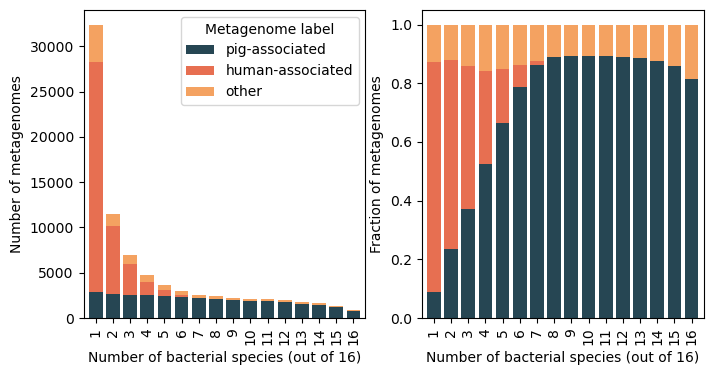

In [18]:
xlabels = df_cm['index'].to_list()
weights = {}
for col in ('cm_pig', 'cm_human', 'cm_other', 'f_pig', 'f_human', 'f_other'):
    weights[col] = df_cm[col].to_list()

labels = {}
labels['cm_human'] = 'human-associated'
labels['cm_other'] = 'other'
labels['cm_pig'] = 'pig-associated'
labels['f_human'] = 'human-associated'
labels['f_other'] = 'other'
labels['f_pig'] = 'pig-associated'

# colormap plotting
colors = {
    'cm_pig': '#264653',
    'cm_human': '#e76f51',
    'cm_other': '#f4a261',
    'f_pig': '#264653',
    'f_human': '#e76f51',
    'f_other': '#f4a261',
    }

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

bottom = np.zeros(len(xlabels))
for name in 'cm_pig', 'cm_human', 'cm_other':
    counts = weights[name]
    axes[0].bar(xlabels, counts, label=labels[name], bottom=bottom, color=colors[name])
    bottom += np.array(counts)

bottom = np.zeros(len(xlabels))
for name in 'f_pig', 'f_human', 'f_other':
    counts = weights[name] 
    axes[1].bar(xlabels, counts, label=labels[name], bottom=bottom, color=colors[name])
    bottom += np.array(counts)

for ax in axes:
    ax.set_xlim(0.3, 16.7)
    ax.set_xlabel('Number of bacterial species (out of 16)')
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(xlabels)

axes[0].legend(title='Metagenome label', loc='upper right')
axes[0].set_ylabel('Number of metagenomes')
axes[1].set_ylabel('Fraction of metagenomes')

plt.savefig('foo.png')

## Figure 1: Core bacteria largely select against human-associated metagenomes.

21-mer search of 700,000 public metagenomes with each of 16 bacterial species pangenomes  found almost 200,000 metagenomes containing at least one species at a containment threshold of 5%. Over 163,000 of these metagenomes were human-associated. Filtering metagenomes based on the number of contained species progressively eliminated the large majority of human metagenomes; when requiring 12 or more species, 80% of the pig metagenomes were retained while only 0.2% of the human metagenomes were retained.

## Calculate enrichment rates

In [19]:
d = metadata2_df['broad_cat'].value_counts().to_dict(as_series=False)

pig_idx = d['broad_cat'].index('pig')
n_orig_pig = d['count'][pig_idx]

human_idx = d['broad_cat'].index('human')
n_orig_human = d['count'][human_idx]

f_orig_pig = n_orig_pig / (n_orig_pig + n_orig_human)
f_orig_human = n_orig_human / (n_orig_pig + n_orig_human)

orig_pig_ratio = n_orig_pig / (n_orig_pig + n_orig_human)
orig_human_ratio = n_orig_human / (n_orig_pig + n_orig_human)

print(orig_pig_ratio, orig_human_ratio)

0.030364534224026338 0.9696354657759737


In [36]:

enrich_df = df_cm.with_columns(
    enrich_pig = (pl.col("cm_pig") / (pl.col("cm_pig") + pl.col("cm_human")) / orig_pig_ratio),
    enrich_human = (pl.col("cm_human") / (pl.col("cm_pig") + pl.col("cm_human")) / orig_human_ratio),
)
with pl.Config(tbl_rows=-1):
    print(enrich_df)

shape: (16, 12)
┌───────┬─────┬───────┬───────┬───┬──────────┬──────────┬────────────┬──────────────┐
│ index ┆ pig ┆ human ┆ other ┆ … ┆ f_human  ┆ f_other  ┆ enrich_pig ┆ enrich_human │
│ ---   ┆ --- ┆ ---   ┆ ---   ┆   ┆ ---      ┆ ---      ┆ ---        ┆ ---          │
│ i64   ┆ i64 ┆ i64   ┆ i64   ┆   ┆ f64      ┆ f64      ┆ f64        ┆ f64          │
╞═══════╪═════╪═══════╪═══════╪═══╪══════════╪══════════╪════════════╪══════════════╡
│ 1     ┆ 123 ┆ 18064 ┆ 2708  ┆ … ┆ 0.786847 ┆ 0.126281 ┆ 3.274472   ┆ 0.928774     │
│ 2     ┆ 108 ┆ 4049  ┆ 404   ┆ … ┆ 0.645842 ┆ 0.120254 ┆ 8.756154   ┆ 0.757113     │
│ 3     ┆ 93  ┆ 1866  ┆ 235   ┆ … ┆ 0.487047 ┆ 0.141048 ┆ 14.259263  ┆ 0.584781     │
│ 4     ┆ 91  ┆ 859   ┆ 195   ┆ … ┆ 0.31931  ┆ 0.15671  ┆ 20.463082  ┆ 0.390506     │
│ 5     ┆ 93  ┆ 440   ┆ 147   ┆ … ┆ 0.182599 ┆ 0.152397 ┆ 25.838372  ┆ 0.222176     │
│ 6     ┆ 88  ┆ 184   ┆ 89    ┆ … ┆ 0.07477  ┆ 0.13759  ┆ 30.077908  ┆ 0.089413     │
│ 7     ┆ 105 ┆ 35    ┆ 52    ┆ … ┆ 0.

(0.0, 40.0)

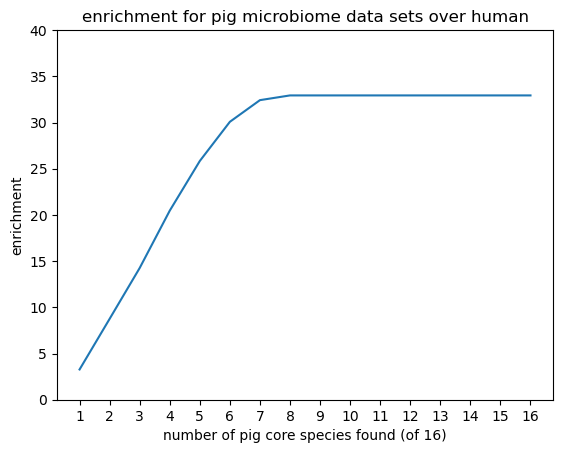

In [21]:
# plt.plot(enrich_df['index'], enrich_df['enrich_human'], label='human enrichment')
plt.plot(enrich_df['index'], enrich_df['enrich_pig'], label='pig enrichment')
plt.title('enrichment for pig microbiome data sets over human')
plt.xlabel('number of pig core species found (of 16)')
plt.ylabel('enrichment')
plt.xticks(range(1, 17))

#plt.legend(loc='upper right')
plt.ylim(0, 40)

## Export the `other` accessions and data sets >= 8 species

In [22]:
other2_df = counts_df.filter((pl.col('count') >= 8))
other2_df = other2_df.join(metadata2_df, on='acc', coalesce=True).select(
    ['acc', 'bioproject', 'organism', 'count', 'broad_cat', 'mbases', 'host', 'project_name']
)
other2_df.write_csv('branchwater_8species_all.csv')

In [23]:
other_df = counts_df.filter((pl.col('count') >= 8) & (pl.col("broad_cat") == "other"))
other_df = other_df.join(metadata2_df, on='acc', coalesce=True).select(
    ['acc', 'bioproject', 'organism', 'count', 'broad_cat', 'mbases', 'host', 'project_name']
)

In [24]:
other_df.write_csv('branchwater_8species_other.csv')

In [25]:
other_df['organism'].value_counts().sort(by='count')

organism,count
str,u32
"""Canis lupus familiaris""",1
"""sludge metagenome""",1
"""clothing metagenome""",1
"""insect metagenome""",1
"""Porcine circovirus 2""",1
…,…
"""synthetic metagenome""",9
"""air metagenome""",9
"""bovine metagenome""",11


In [26]:
other_df

acc,bioproject,organism,count,broad_cat,mbases,host,project_name
str,str,str,u32,str,i64,str,str
"""ERR3574843""","""PRJEB34634""","""sediment metagenome""",16,"""other""",1609,null,"""[""REHAB""]"""
"""SRR3053217""","""PRJNA292471""","""bovine metagenome""",8,"""other""",1265,"""[""Bos taurus""]""",null
"""ERR12327373""","""PRJEB66439""","""Canis lupus familiaris""",10,"""other""",2949,null,"""[""HUNT ONE HEALTH""]"""
"""ERR3211536""","""PRJEB31650""","""wastewater metagenome""",8,"""other""",1950,null,null
"""ERR3574765""","""PRJEB34634""","""sediment metagenome""",16,"""other""",1706,null,"""[""REHAB""]"""
…,…,…,…,…,…,…,…
"""ERR3574838""","""PRJEB34634""","""sediment metagenome""",16,"""other""",1585,null,"""[""REHAB""]"""
"""ERR3574488""","""PRJEB34634""","""sediment metagenome""",15,"""other""",1712,null,"""[""REHAB""]"""
"""ERR3574477""","""PRJEB34634""","""sediment metagenome""",15,"""other""",1649,null,"""[""REHAB""]"""


In [27]:
metadata2_df

sample_name,sample_name_sam,acc,assay_type,avgspotlen,bioproject,biosample,biosamplemodel_sam,center_name,collection_date_sam,consent,datastore_filetype,datastore_provider,datastore_region,ena_first_public_run,ena_last_update_run,experiment,geo_loc_name_country_calc,geo_loc_name_country_continent_calc,geo_loc_name_sam,insertsize,instrument,library_name,librarylayout,libraryselection,librarysource,loaddate,mbases,mbytes,organism,platform,releasedate,sample_acc,sra_study,age,altitude,body_habitat,body_product,collection_date,depth,env_biome,env_broad_scale,env_feature,env_local_scale,env_material,env_medium,env_package,host,host_age,host_body_habitat,host_body_product,host_common_name,host_sex,host_subject_id,host_taxid,investigation_type,isolate,lat_lon,project_name,race,sample_type,source_material_id,bases,bytes,run_file_create_date,run_file_version,primary_search,broad_cat
str,list[str],str,str,i64,str,str,list[str],str,date,str,list[str],list[str],list[str],list[str],list[str],str,str,str,list[str],i64,str,str,str,str,str,"datetime[μs, UTC]",i64,i64,str,str,"datetime[μs, UTC]",str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""27""",[],"""SRR28523869""","""WGS""",5336,"""PRJNA1095378""","""SAMN40717046""","[""MIMARKS.survey"", ""MIGS/MIMS/MIMARKS.human-associated""]","""UNIVERSITY OF FLORIDA""",2019-01-21,"""public""","[""fastq"", ""sra""]","[""gs"", ""ncbi"", ""s3""]","[""gs.us-east1"", ""ncbi.public"", ""s3.us-east-1""]",[],[],"""SRX24124678""","""USA""","""North America""","[""USA""]",null,"""MinION""","""27""","""SINGLE""","""RANDOM""","""METAGENOMIC""",null,258,221,"""human metagenome""","""OXFORD_NANOPORE""",2024-04-02 00:00:00 UTC,"""SRS20910198""","""SRP499205""",null,null,null,null,"""[""2019-01-21""]""",null,null,"""[""human stool""]""",null,"""[""preterm neonate stool""]""",null,"""[""not applicable""]""",null,"""[""Homo sapiens""]""",null,null,null,null,null,null,null,null,null,"""""29.6520 N 82.3250 W""""",null,null,null,null,"""258178589""","""232696690""","""""2024-04-02T09:18:00.000Z""""",null,"""""1095378""""","""human"""
"""CN20""",[],"""SRR19901137""","""WGS""",709,"""PRJNA854064""","""SAMN29417614""","[""Pathogen.cl""]","""ACADEMY OF MILITARY MEDICAL SC…",null,"""public""","[""fastq"", ""run.zq"", ""sra""]","[""gs"", ""ncbi"", ""s3""]","[""gs.us-east1"", ""ncbi.public"", ""s3.us-east-1""]",[],[],"""SRX15943916""","""China""","""Asia""","[""China""]",null,"""MinION""","""CN20""","""SINGLE""","""RANDOM PCR""","""METAGENOMIC""",null,40,35,"""Streptococcus suis""","""OXFORD_NANOPORE""",2022-06-29 00:00:00 UTC,"""SRS13630891""","""SRP384224""",null,null,null,null,"""[""2020""]""",null,null,null,null,null,null,null,null,"""[""Homo sapiens""]""",null,null,null,null,null,null,null,null,null,"""""39.56 N 116.246 E""""",null,null,null,null,"""40695094""","""37326224""","""""2022-06-29T14:47:00.000Z""""",null,"""""29417614""""","""other"""
"""9419-17""",[],"""SRR24962475""","""WGS""",2830,"""PRJNA982891""","""SAMN35766867""","[""Pathogen.cl""]","""UNIVERSITY OF QUEENSLAND""",null,"""public""","[""fastq"", ""sra""]","[""gs"", ""ncbi"", ""s3""]","[""gs.us-east1"", ""ncbi.public"", ""s3.us-east-1""]",[],[],"""SRX20720528""","""Australia""","""Oceania""","[""Australia""]",null,"""MinION""","""9419-17ONTBC""","""SINGLE""","""RANDOM""","""METAGENOMIC""",null,88,77,"""Escherichia coli""","""OXFORD_NANOPORE""",2023-06-19 00:00:00 UTC,"""SRS18011968""","""SRP444682""",null,null,null,null,"""[""2021""]""",null,null,null,null,null,null,null,null,"""[""Homo sapiens""]""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""88439849""","""81459369""","""""2023-06-19T19:32:00.000Z""""",null,"""""35766867""""","""other"""
"""P36""",[],"""SRR29161330""","""WGS""",1250,"""PRJNA1116137""","""SAMN41523629""","[""Metagenome or environmental""]","""THE OHIO STATE UNIVERSITY""",2018-04-13,"""public""","[""fastq"", ""sra""]"

In [28]:
other_sum_df = other_df.group_by('bioproject').agg(
    n_found=pl.len()
).sort('n_found')
other_sum_df

bioproject,n_found
str,u32
"""PRJNA1044412""",1
"""PRJNA863608""",1
"""PRJNA832246""",1
"""PRJNA527324""",1
"""PRJNA319008""",1
…,…
"""PRJNA892010""",7
"""PRJNA526405""",8
"""PRJNA292471""",9


In [29]:
total_sum_df = metadata2_df.join(other_sum_df, on='bioproject', how='semi').group_by('bioproject').agg(
    total=pl.len(),
    total_pig=pl.col('broad_cat').filter(pl.col('broad_cat') == 'pig').len(),
    total_other=pl.col('broad_cat').filter(pl.col('broad_cat') == 'other').len(),

)
total_sum_df

bioproject,total,total_pig,total_other
str,u32,u32,u32
"""PRJNA292471""",87,0,87
"""PRJNA843354""",32,0,32
"""PRJNA832246""",28,0,28
"""PRJEB34634""",2076,0,2076
"""PRJNA745489""",1,0,1
…,…,…,…
"""PRJNA623064""",84,0,84
"""PRJEB40798""",150,0,150
"""PRJNA527324""",24,0,24


In [30]:
combo_sum_df = (
    other_sum_df
    .join(total_sum_df, on='bioproject', how='inner')
    .with_columns(
        f_found=pl.col('n_found') / pl.col('total')
    )
    .sort('f_found')
)
combo_sum_df

bioproject,n_found,total,total_pig,total_other,f_found
str,u32,u32,u32,u32,f64
"""PRJNA526405""",8,3598,3423,175,0.002223
"""PRJEB66439""",2,408,0,408,0.004902
"""PRJNA561080""",2,294,0,294,0.006803
"""PRJNA385554""",1,120,0,120,0.008333
"""PRJEB31650""",5,567,287,280,0.008818
…,…,…,…,…,…
"""PRJNA684647""",3,18,0,18,0.166667
"""PRJNA699174""",5,24,0,24,0.208333
"""PRJNA892010""",7,27,0,27,0.259259


In [31]:
combo_sum_df.sort('n_found').filter(pl.col('n_found') > 2)

bioproject,n_found,total,total_pig,total_other,f_found
str,u32,u32,u32,u32,f64
"""PRJNA1121201""",3,97,52,45,0.030928
"""PRJNA623064""",3,84,0,84,0.035714
"""PRJNA684647""",3,18,0,18,0.166667
"""PRJEB31650""",5,567,287,280,0.008818
"""PRJNA699174""",5,24,0,24,0.208333
"""PRJNA892010""",7,27,0,27,0.259259
"""PRJNA526405""",8,3598,3423,175,0.002223
"""PRJNA292471""",9,87,0,87,0.103448
"""PRJNA506496""",32,39,0,39,0.820513


In [32]:
metadata2_df.filter(pl.col('bioproject') == 'PRJNA526405')['organism'].value_counts()

organism,count
str,u32
"""synthetic metagenome""",100
"""metagenome""",75
"""pig gut metagenome""",3423
